**Name**: `Dixin Zhang`

**Date**: `20/4/2026`

# 1 Import Data

In [1]:
import kagglehub
path = kagglehub.dataset_download("moimransiddiqui/ads-ctr-optimistaion")

100%|██████████| 18.6k/18.6k [00:00<00:00, 30.3MB/s]

Extracting files...


In [2]:
import os
import glob
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("moimransiddiqui/ads-ctr-optimistaion")
print("Downloaded to:", path)

for root, dirs, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))

csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
print("CSV files found:", csv_files)

df = pd.read_csv(csv_files[0])

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nHead:")
display(df.head())

print("\nUnique values per column:")
for col in df.columns:
    print(col, sorted(df[col].dropna().unique())[:10])

Using Colab cache for faster access to the 'ads-ctr-optimistaion' dataset.
Downloaded to: /kaggle/input/ads-ctr-optimistaion
/kaggle/input/ads-ctr-optimistaion/Ads_CTR_Optimisation.csv
CSV files found: ['/kaggle/input/ads-ctr-optimistaion/Ads_CTR_Optimisation.csv']
Shape: (10000, 10)

Columns:
['Ad 1', 'Ad 2', 'Ad 3', 'Ad 4', 'Ad 5', 'Ad 6', 'Ad 7', 'Ad 8', 'Ad 9', 'Ad 10']

Head:


,Ad 1,Ad 2,Ad 3,Ad 4,Ad 5,Ad 6,Ad 7,Ad 8,Ad 9,Ad 10
0,1,0,0,0,1,0,0,0,1,0
1,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0



Unique values per column:
Ad 1 [np.int64(0), np.int64(1)]
Ad 2 [np.int64(0), np.int64(1)]
Ad 3 [np.int64(0), np.int64(1)]
Ad 4 [np.int64(0), np.int64(1)]
Ad 5 [np.int64(0), np.int64(1)]
Ad 6 [np.int64(0), np.int64(1)]
Ad 7 [np.int64(0), np.int64(1)]
Ad 8 [np.int64(0), np.int64(1)]
Ad 9 [np.int64(0), np.int64(1)]
Ad 10 [np.int64(0), np.int64(1)]


In [3]:
import numpy as np
import matplotlib.pyplot as plt

data = df.values
T, k = data.shape

print("Rounds:", T)
print("Number of ads (arms):", k)

Rounds: 10000
Number of ads (arms): 10


# 2. ε-greedy

action-value + sample-average + ε-greedy

In [16]:
def run_epsilon_greedy(data, epsilon=0.1):
    T, k = data.shape

    Q = np.zeros(k)   # estimated CTR for each ad
    N = np.zeros(k)   # how many times each ad has been selected

    rewards = []
    chosen_arms = []

    for t in range(T):
        # exploration vs exploitation
        if np.random.rand() < epsilon:
            arm = np.random.randint(k)   # explore
        else:
            max_q = np.max(Q)
            candidates = np.where(Q == max_q)[0]
            arm = np.random.choice(candidates)           # exploit

        reward = data[t, arm]

        N[arm] += 1
        Q[arm] += (reward - Q[arm]) / N[arm]   # sample-average update

        rewards.append(reward)
        chosen_arms.append(arm)

    return np.array(rewards), np.array(chosen_arms), Q, N

In [17]:
np.random.seed(42)

eg_rewards, eg_arms, eg_Q, eg_N = run_epsilon_greedy(data, epsilon=0.1)

print("Total clicks:", eg_rewards.sum())
print("Estimated CTRs:", eg_Q)
print("Selection counts:", eg_N.astype(int))
print("Best estimated ad:", np.argmax(eg_Q) + 1)

Total clicks: 2418
Estimated CTRs: [0.1640625  0.17757009 0.06593407 0.08247423 0.26828913 0.00925926
 0.14563107 0.21481806 0.09009009 0.0625    ]
Selection counts: [ 128  107   91   97 6862  108  103 2281  111  112]
Best estimated ad: 5


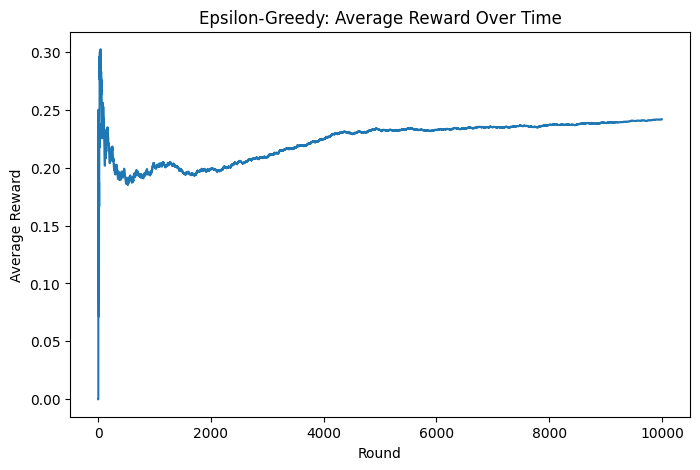

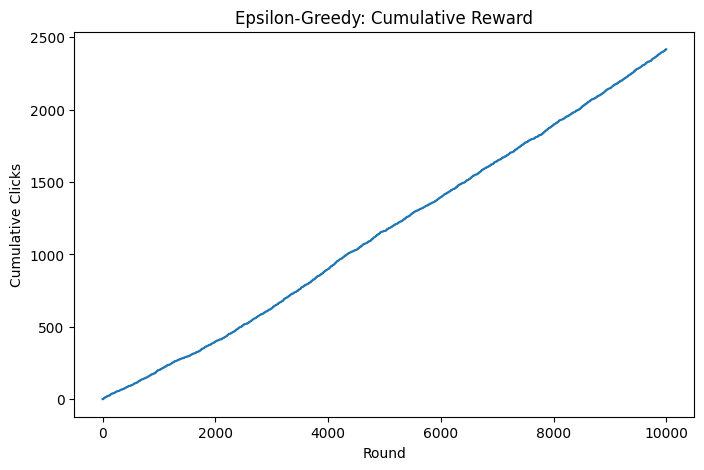

In [18]:
avg_reward = np.cumsum(eg_rewards) / np.arange(1, T + 1)
cum_reward = np.cumsum(eg_rewards)

plt.figure(figsize=(8,5))
plt.plot(avg_reward)
plt.xlabel("Round")
plt.ylabel("Average Reward")
plt.title("Epsilon-Greedy: Average Reward Over Time")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(cum_reward)
plt.xlabel("Round")
plt.ylabel("Cumulative Clicks")
plt.title("Epsilon-Greedy: Cumulative Reward")
plt.show()

In [20]:
true_ctr = df.mean(axis=0)
print(true_ctr)
print("Best actual ad:", true_ctr.idxmax(), "CTR =", true_ctr.max())

Ad 1     0.1703
Ad 2     0.1295
Ad 3     0.0728
Ad 4     0.1196
Ad 5     0.2695
Ad 6     0.0126
Ad 7     0.1112
Ad 8     0.2091
Ad 9     0.0952
Ad 10    0.0489
dtype: float64
Best actual ad: Ad 5 CTR = 0.2695


# 3. UCB

In [29]:
def run_ucb(data, c=2.0):
    T, k = data.shape

    Q = np.zeros(k)
    N = np.zeros(k)

    rewards = []
    chosen_arms = []

    for t in range(T):
        if t < k:
            arm = t  # try each arm once during warm-up
        else:
            ucb_values = Q + c * np.sqrt(np.log(t + 1) / N)
            max_ucb = np.max(ucb_values)
            candidates = np.where(ucb_values == max_ucb)[0]
            arm = np.random.choice(candidates)  # random tie-breaking

        reward = data[t, arm]

        N[arm] += 1
        Q[arm] += (reward - Q[arm]) / N[arm]

        rewards.append(reward)
        chosen_arms.append(arm)

    return np.array(rewards), np.array(chosen_arms), Q, N

In [30]:
np.random.seed(42)

ucb_rewards, ucb_arms, ucb_Q, ucb_N = run_ucb(data, c=2.0)

print("Total clicks:", ucb_rewards.sum())
print("Estimated CTRs:", ucb_Q)
print("Selection counts:", ucb_N.astype(int))
print("Best estimated ad:", np.argmax(ucb_Q) + 1)

Total clicks: 1894
Estimated CTRs: [0.16770186 0.14649682 0.05626598 0.13323782 0.27190121 0.01923077
 0.0965251  0.18356643 0.09867173 0.04632153]
Selection counts: [ 966  785  391  698 4292  312  518 1144  527  367]
Best estimated ad: 5


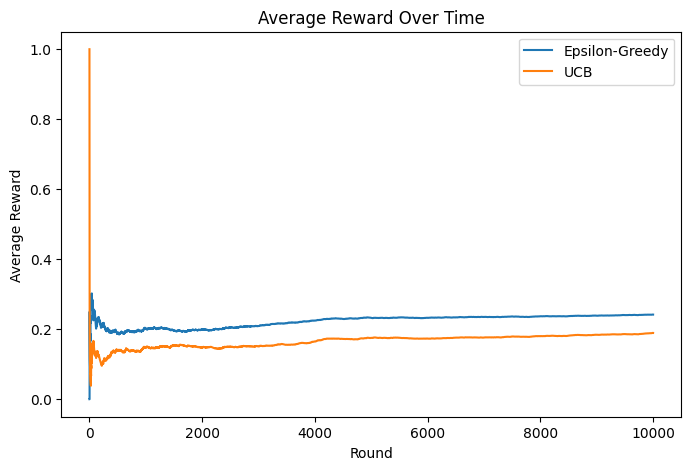

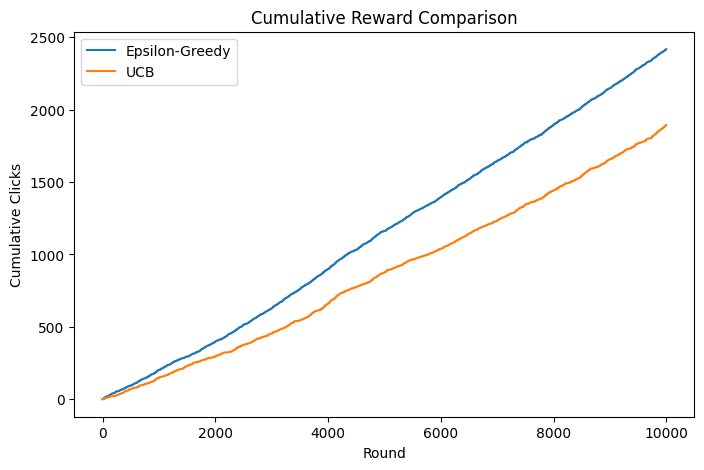

In [31]:
eg_avg = np.cumsum(eg_rewards) / np.arange(1, T + 1)
ucb_avg = np.cumsum(ucb_rewards) / np.arange(1, T + 1)

eg_cum = np.cumsum(eg_rewards)
ucb_cum = np.cumsum(ucb_rewards)

plt.figure(figsize=(8,5))
plt.plot(eg_avg, label="Epsilon-Greedy")
plt.plot(ucb_avg, label="UCB")
plt.xlabel("Round")
plt.ylabel("Average Reward")
plt.title("Average Reward Over Time")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(eg_cum, label="Epsilon-Greedy")
plt.plot(ucb_cum, label="UCB")
plt.xlabel("Round")
plt.ylabel("Cumulative Clicks")
plt.title("Cumulative Reward Comparison")
plt.legend()
plt.show()

In [32]:
comparison = pd.DataFrame({
    "Ad": [f"Ad {i+1}" for i in range(k)],
    "True CTR": true_ctr.values,
    "EG Estimated CTR": eg_Q,
    "EG Selections": eg_N.astype(int),
    "UCB Estimated CTR": ucb_Q,
    "UCB Selections": ucb_N.astype(int),
})

display(comparison.sort_values("True CTR", ascending=False))

,Ad,True CTR,EG Estimated CTR,EG Selections,UCB Estimated CTR,UCB Selections
4,Ad 5,0.2695,0.268289,6862,0.271901,4292
7,Ad 8,0.2091,0.214818,2281,0.183566,1144
0,Ad 1,0.1703,0.164062,128,0.167702,966
1,Ad 2,0.1295,0.177570,107,0.146497,785
3,Ad 4,0.1196,0.082474,97,0.133238,698
6,Ad 7,0.1112,0.145631,103,0.096525,518
8,Ad 9,0.0952,0.090090,111,0.098672,527
2,Ad 3,0.0728,0.065934,91,0.056266,391
9,Ad 10,0.0489,0.062500,112,0.046322,367
5,Ad 6,0.0126,0.009259,108,0.019231,312


# 4.conclution

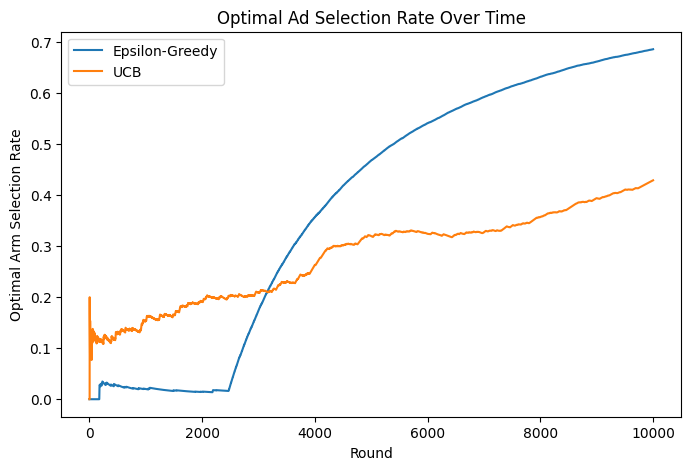

In [33]:
best_arm_index = np.argmax(true_ctr.values)

eg_optimal_rate = np.cumsum(eg_arms == best_arm_index) / np.arange(1, T + 1)
ucb_optimal_rate = np.cumsum(ucb_arms == best_arm_index) / np.arange(1, T + 1)

plt.figure(figsize=(8,5))
plt.plot(eg_optimal_rate, label="Epsilon-Greedy")
plt.plot(ucb_optimal_rate, label="UCB")
plt.xlabel("Round")
plt.ylabel("Optimal Arm Selection Rate")
plt.title("Optimal Ad Selection Rate Over Time")
plt.legend()
plt.show()

In [34]:
print("Final EG optimal-arm rate:", eg_optimal_rate[-1])
print("Final UCB optimal-arm rate:", ucb_optimal_rate[-1])

Final EG optimal-arm rate: 0.6862
Final UCB optimal-arm rate: 0.4292


# Results Interpretation

Both ε-greedy and UCB successfully identified Ad 5 as the optimal banner. However, ε-greedy selected the optimal ad much more frequently (68.62%) than UCB (42.92%), which indicates that ε-greedy shifted to exploitation faster on this dataset. UCB explored a wider range of ads for longer, which is consistent with its design of favoring uncertain actions through an upper-confidence bonus. In this dataset, where one ad clearly has the highest CTR, faster exploitation appears to produce better practical performance.